# 06 – Association rules (ARM)

**Purpose:** Find rules of the type

> `kommungrupp=C` & `bnp_indikator=svag` → `fruktsamhet=hög`

and test whether they hold on years the model has not seen.

| | |
|---|---|
| **Input** | `data/processed/arm_underlag_lag1.csv` (main analysis), `arm_underlag_lag2.csv` (sensitivity), from `05` |
| **Output** | `resultat/arm_regler_lag1.csv`, `resultat/arm_regler_lag2.csv`, `resultat/arm_regler_lag1_utan_bortfall.csv`, figures `resultat/arm_*.png` |
| **Dependencies** | Run `05` first. The `mlxtend` package is needed. |

### How to read a rule `X → Y`
- **Support:** share of all transactions where both X and Y hold.
- **Confidence:** share of the transactions with X where Y also holds, i.e. the probability of Y given X.
- **Lift:** confidence divided by the overall share of Y. Lift > 1 means that X makes Y more common than average.

### Two extra measures for this particular data
The standard measures are not enough here, for two reasons:

1. **The municipality type explains a lot on its own.** If C municipalities often have high fertility, *every* rule that starts with `kommungrupp=C` gets a high lift, regardless of the business cycle. The measure **tillskott** (added confidence) therefore compares the rule's confidence with *the same municipality group without any business cycle condition*. The added confidence shows what the business cycle contributes beyond the municipality type, and that is what the research question is about.
2. **The business cycle is national.** A business cycle condition applies to all municipalities in the same year. A rule can have thousands of supporting municipality-years and still rest on only two different years. The measure **antal_ar** (number of years) counts how many different years lie behind the rule. This is the real number of independent observations of the business cycle.

## 1. Settings and parameters

- `MIN_SUPPORT`: minimum support for an itemset to count as frequent. The threshold is low (1 %) because combinations of municipality group and business cycle class are naturally rare. The actual selection is made with the following conditions.
- `MIN_AR`: minimum number of *different years* behind a rule. With fewer years, the rule is an anecdote.
- `MIN_TILLSKOTT`: the business cycle condition must raise confidence by at least this much (as a proportion) compared with the municipality group alone.
- `MIN_AR_TEST`: a rule counts as **stable** if it has a positive added confidence on the test years too and is based on at least this many test years.


In [1]:
from pathlib import Path

import pandas as pd

from mlxtend.frequent_patterns import association_rules, fpgrowth

BAS = Path.cwd()
if not (BAS / "data" / "raw").is_dir() and (BAS / "Assignment").is_dir():
    BAS = BAS / "Assignment"

RAW = BAS / "data" / "raw"
PROCESSED = BAS / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

assert RAW.is_dir(), "Cannot find data/raw. Open the notebook from the Assignment folder."

RESULTAT = BAS / "resultat"
RESULTAT.mkdir(exist_ok=True)

INDIKATORER = ["bnp_indikator", "hushallens_konsumtion", "sysselsattning"]
MIN_SUPPORT = 0.01
MAX_LANGD = 5
MIN_AR = 3
MIN_TILLSKOTT = 0.05
MIN_AR_TEST = 2

## 2. Helper functions

Three functions are used in both the main analysis and the sensitivity analysis. That is why they are defined once here.

- `till_items`: turns a row of classes into **items** in the form of true/false columns, for example `kommungrupp=C` and `bnp_indikator=svag`. All possible classes are always created, even if a class is absent in a particular period. Training and test data then have exactly the same columns.
- `matt`: computes support, confidence, lift and number of different years for a rule on any dataset. The same function is used on training and test data, so that the measures are computed in an identical way.
- `ar_regeltyp`: decides whether a rule answers the research question. The requirements are that the consequent is exactly one fertility class and that the antecedent contains exactly one municipality group, at least one business cycle condition and no fertility class.

In [2]:
KATEGORIER = {
    "kommungrupp": ["A", "B", "C"],
    "fruktsamhet": ["låg", "medel", "hög"],
    **{ind: ["svag", "normal", "stark"] for ind in INDIKATORER},
}
KALLKOLUMN = {"kommungrupp": "kommungrupp", "fruktsamhet": "fruktsamhet_klass",
              **{ind: f"{ind}_klass" for ind in INDIKATORER}}


def till_items(df):
    """One true/false column per item, e.g. 'kommungrupp=C'."""
    kolumner = {f"{namn}={klass}": df[KALLKOLUMN[namn]].eq(klass)
                for namn, klasser in KATEGORIER.items() for klass in klasser}
    return pd.DataFrame(kolumner, index=df.index)


def matt(items, ar, villkor, slutled):
    """Support, confidence, lift and number of different years for the rule antecedent → consequent."""
    har_villkor = items[list(villkor)].all(axis=1)
    if har_villkor.sum() == 0:
        return {"support": 0.0, "confidence": float("nan"), "lift": float("nan"), "antal_ar": 0}
    traffar = har_villkor & items[slutled]
    confidence = traffar.sum() / har_villkor.sum()
    return {
        "support": traffar.mean(),
        "confidence": confidence,
        "lift": confidence / items[slutled].mean(),
        "antal_ar": ar[har_villkor].nunique(),
    }


def ar_regeltyp(villkor, slutled):
    """Does the rule answer the research question?"""
    typ = lambda item: item.split("=")[0]
    return (
        len(slutled) == 1 and typ(next(iter(slutled))) == "fruktsamhet"
        and sum(typ(i) == "kommungrupp" for i in villkor) == 1
        and sum(typ(i) in INDIKATORER for i in villkor) >= 1
        and not any(typ(i) == "fruktsamhet" for i in villkor)
    )

## 3. Load the dataset and create transactions

The main analysis uses a **1-year lag**. Each row (municipality and year) becomes a transaction with five items: municipality group, fertility class and one class per business cycle indicator. The transactions are split into training and test according to the `del` column from `05`.

In [3]:
underlag = pd.read_csv(PROCESSED / "arm_underlag_lag1.csv", encoding="utf-8-sig", dtype={"Kommunkod": str})

items = till_items(underlag)
assert (items.sum(axis=1) == len(KATEGORIER)).all(), "Each transaction must have exactly one item per variable."

tran = underlag["del"] == "traning"
items_tran, ar_tran = items.loc[tran], underlag.loc[tran, "ar"]
items_test, ar_test = items.loc[~tran], underlag.loc[~tran, "ar"]

print(f"Transactions: {len(items_tran)} training ({ar_tran.min()}–{ar_tran.max()}), "
      f"{len(items_test)} test ({ar_test.min()}–{ar_test.max()})")
display(items.head(3))

Transactions: 3663 training (2003–2015), 2804 test (2016–2025)


,kommungrupp=A,kommungrupp=B,kommungrupp=C,fruktsamhet=låg,fruktsamhet=medel,fruktsamhet=hög,bnp_indikator=svag,bnp_indikator=normal,bnp_indikator=stark,hushallens_konsumtion=svag,hushallens_konsumtion=normal,hushallens_konsumtion=stark,sysselsattning=svag,sysselsattning=normal,sysselsattning=stark
0,True,False,False,False,True,False,False,True,False,False,True,False,False,False,True
1,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False
2,True,False,False,False,True,False,False,True,False,True,False,False,True,False,False


## 4. Baseline: fertility per municipality group

Before the business cycle is included, we show how the fertility classes are distributed within each municipality group. This is the baseline that every rule is compared with. The value is the confidence of the rule `kommungrupp=X → fruktsamhet=Y`.

The differences between the groups are a result in themselves. They show structural differences between the municipality types regardless of the business cycle.

In [4]:
for del_ in ["traning", "test"]:
    print(f"\nShare per fertility class within municipality group – {del_}:")
    tabell = pd.crosstab(underlag.loc[underlag["del"] == del_, "kommungrupp"],
                         underlag.loc[underlag["del"] == del_, "fruktsamhet_klass"], normalize="index")
    display(tabell[KATEGORIER["fruktsamhet"]].round(3))


Share per fertility class within municipality group – traning:


fruktsamhet_klass,låg,medel,hög
kommungrupp,,,
A,0.256,0.381,0.363
B,0.354,0.310,0.336
C,0.353,0.330,0.317



Share per fertility class within municipality group – test:


fruktsamhet_klass,låg,medel,hög
kommungrupp,,,
A,0.361,0.424,0.215
B,0.280,0.321,0.399
C,0.267,0.349,0.384


## 5. Find frequent itemsets with FP-growth

**FP-growth** finds all combinations of items that occur in at least `MIN_SUPPORT` of the training transactions. It gives the same result as *Apriori* but is faster, since it does not need to scan the data once per itemset size.

Only **training data** is used. The test years are kept completely separate until the rules are to be tested.

In [5]:
frekventa = fpgrowth(items_tran, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LANGD)
print(f"Frequent itemsets: {len(frekventa)}")
print(frekventa["itemsets"].map(len).value_counts().sort_index().rename("count per size"))

Frequent itemsets: 508
itemsets
1     15
2     81
3    194
4    171
5     47
Name: count per size, dtype: int64


## 6. Generate rules and keep those that answer the question

`association_rules` generates all possible rules from the frequent itemsets. Most of them are about something other than the research question, for example that two business cycle indicators are often weak at the same time. Such rules say something about the business cycle, not about fertility.

We keep only rules where **the consequent is a fertility class** and the antecedent contains **one municipality group and at least one business cycle condition** (see `ar_regeltyp`).

As a check, the training measures are recomputed with our own function `matt`. They must match mlxtend's exactly. Then we know that the same definitions are used when the rules are tested on test data.

In [6]:
alla_regler = association_rules(frekventa, num_itemsets=len(items_tran), metric="confidence", min_threshold=0.0)
regler = alla_regler.loc[[ar_regeltyp(v, s) for v, s in zip(alla_regler["antecedents"], alla_regler["consequents"])]]
regler = pd.DataFrame({
    "villkor": [tuple(sorted(v)) for v in regler["antecedents"]],
    "slutled": [next(iter(s)) for s in regler["consequents"]],
    "confidence_mlxtend": regler["confidence"].to_numpy(),
})

for v, s, c in zip(regler["villkor"], regler["slutled"], regler["confidence_mlxtend"]):
    assert abs(matt(items_tran, ar_tran, v, s)["confidence"] - c) < 1e-12

print(f"All rules: {len(alla_regler)}. Rules that answer the question: {len(regler)}")

All rules: 5130. Rules that answer the question: 241


## 7. Measure the rules on training and test years

For each rule, the following are computed on both training and test data:

- support, confidence, lift and **antal_ar** (number of different years behind the antecedent)
- **bas_confidence**: confidence for the same municipality group without any business cycle condition
- **tillskott** (added confidence) = confidence − bas_confidence, i.e. what the business cycle contributes beyond the municipality type.

If the antecedent never occurs during the test period (for example a business cycle class that did not occur), the rule cannot be tested, and the test measures are empty.

In [7]:
def utvardera(regler, items, ar, suffix):
    rader = []
    for villkor, slutled in zip(regler["villkor"], regler["slutled"]):
        m = matt(items, ar, villkor, slutled)
        grupp = next(i for i in villkor if i.startswith("kommungrupp="))
        m["bas_confidence"] = matt(items, ar, (grupp,), slutled)["confidence"]
        m["tillskott"] = m["confidence"] - m["bas_confidence"]
        rader.append({f"{k}_{suffix}": v for k, v in m.items()})
    return pd.DataFrame(rader, index=regler.index)


def utvardera_bada(regler, items_tran, ar_tran, items_test, ar_test):
    return pd.concat([regler[["villkor", "slutled"]],
                      utvardera(regler, items_tran, ar_tran, "tran"),
                      utvardera(regler, items_test, ar_test, "test")], axis=1)


matta = utvardera_bada(regler, items_tran, ar_tran, items_test, ar_test)
print("Measured rules:", len(matta))

Measured rules: 241


## 8. Select rules and test whether they are stable

A rule is **selected** if on the training years it meets both conditions:
- it is based on at least `MIN_AR` different years
- the business cycle condition raises confidence by at least `MIN_TILLSKOTT` compared with the municipality group alone.

A selected rule counts as **stable** if the added confidence is positive on the test years too and is based on at least `MIN_AR_TEST` test years. A rule that only holds on the training years may be a coincidence in the years it was found on.

The *stable* criterion only requires the added confidence to be **positive** on the test years. So also look at **how large** it is. A test added confidence of just a few percentage points is weak support, even if the rule formally counts as stable.

In [8]:
def valj_och_prova(matta):
    valda = matta.loc[(matta["antal_ar_tran"] >= MIN_AR) & (matta["tillskott_tran"] >= MIN_TILLSKOTT)].copy()
    valda["stabil"] = (valda["tillskott_test"] > 0) & (valda["antal_ar_test"] >= MIN_AR_TEST)
    valda["provbar"] = valda["antal_ar_test"] >= MIN_AR_TEST
    return valda.sort_values(["tillskott_tran", "slutled", "villkor"], ascending=[False, True, True])


valda = valj_och_prova(matta)
print(f"Selected on the training years: {len(valda)}")
print(f"Testable (the antecedent occurs in at least {MIN_AR_TEST} test years): {valda['provbar'].sum()}")
print(f"Stable (positive added confidence on the test years too): {valda['stabil'].sum()}")

Selected on the training years: 5
Testable (the antecedent occurs in at least 2 test years): 2
Stable (positive added confidence on the test years too): 1


## 9. Results

The table shows the selected rules sorted by added confidence on the training years.

- **confidence_tran** and **bas_confidence_tran**: how often the consequent holds with and without the business cycle condition, respectively.
- **antal_ar_tran**: how many different years the rule rests on. Few years means weak support, even if support looks high.
- **tillskott_test** and **stabil**: whether the pattern recurs during 2016–2025.

In [9]:
visa = valda.assign(villkor=valda["villkor"].map(" & ".join))[[
    "villkor", "slutled", "support_tran", "confidence_tran", "bas_confidence_tran", "tillskott_tran",
    "lift_tran", "antal_ar_tran", "confidence_test", "tillskott_test", "antal_ar_test", "stabil",
]]
pd.set_option("display.max_colwidth", 90)
display(visa.round(3).reset_index(drop=True))

,villkor,slutled,support_tran,confidence_tran,bas_confidence_tran,tillskott_tran,lift_tran,antal_ar_tran,confidence_test,tillskott_test,antal_ar_test,stabil
0,kommungrupp=A & sysselsattning=stark,fruktsamhet=hög,0.017,0.449,0.363,0.086,1.354,3,0.235,0.020,5,True
1,hushallens_konsumtion=svag & kommungrupp=A & sysselsattning=normal,fruktsamhet=låg,0.016,0.321,0.256,0.065,0.950,4,0.239,-0.122,1,False
2,bnp_indikator=svag & hushallens_konsumtion=svag & kommungrupp=A & sysselsattning=normal,fruktsamhet=låg,0.012,0.312,0.256,0.056,0.923,3,0.239,-0.122,1,False
3,bnp_indikator=svag & kommungrupp=A & sysselsattning=normal,fruktsamhet=låg,0.012,0.312,0.256,0.056,0.923,3,0.239,-0.122,1,False
4,bnp_indikator=normal & hushallens_konsumtion=normal & kommungrupp=A,fruktsamhet=hög,0.016,0.413,0.363,0.050,1.245,3,0.207,-0.009,2,False


## 10. Sensitivity analysis

Does the result hold if we change the assumptions that are most uncertain? The same procedure is run two more times:

1. **2-year lag** instead of 1.
2. **1-year lag without municipalities with missing data.** Municipalities with missing or interpolated values are removed (the `har_bortfall` flag from `02`), so that noise from the small municipalities does not drive the result.

For each run, the number of selected and stable rules is reported, along with how many of the stable rules are also stable in the main analysis.

In [10]:
def kor_arm(underlag):
    items = till_items(underlag)
    tran = underlag["del"] == "traning"
    it_tran, a_tran = items.loc[tran], underlag.loc[tran, "ar"]
    it_test, a_test = items.loc[~tran], underlag.loc[~tran, "ar"]
    frek = fpgrowth(it_tran, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LANGD)
    alla = association_rules(frek, num_itemsets=len(it_tran), metric="confidence", min_threshold=0.0)
    alla = alla.loc[[ar_regeltyp(v, s) for v, s in zip(alla["antecedents"], alla["consequents"])]]
    kandidater = pd.DataFrame({"villkor": [tuple(sorted(v)) for v in alla["antecedents"]],
                               "slutled": [next(iter(s)) for s in alla["consequents"]]})
    return valj_och_prova(utvardera_bada(kandidater, it_tran, a_tran, it_test, a_test))


lag2 = pd.read_csv(PROCESSED / "arm_underlag_lag2.csv", encoding="utf-8-sig", dtype={"Kommunkod": str})
korningar = {
    "lag1 (main analysis)": valda,
    "lag2": kor_arm(lag2),
    "lag1 without missing data": kor_arm(underlag.loc[~underlag["har_bortfall"]]),
}

stabila_huvud = set(zip(valda.loc[valda["stabil"], "villkor"], valda.loc[valda["stabil"], "slutled"]))
sammanfattning = pd.DataFrame({
    namn: {
        "selected": len(df),
        "stable": int(df["stabil"].sum()),
        "stable that are also stable in the main analysis": len(
            stabila_huvud & set(zip(df.loc[df["stabil"], "villkor"], df.loc[df["stabil"], "slutled"]))),
    }
    for namn, df in korningar.items()
}).T
display(sammanfattning)

,selected,stable,stable that are also stable in the main analysis
lag1 (main analysis),5,1,1
lag2,7,1,1
lag1 without missing data,5,1,1


## 11. Save

The rules from each run are saved with training and test measures. The antecedent is saved as text with items separated by ` & `.

In [11]:
filnamn = {"lag1 (main analysis)": "arm_regler_lag1.csv", "lag2": "arm_regler_lag2.csv",
           "lag1 without missing data": "arm_regler_lag1_utan_bortfall.csv"}
for namn, df in korningar.items():
    utfil = RESULTAT / filnamn[namn]
    df.assign(villkor=df["villkor"].map(" & ".join)).to_csv(utfil, index=False, encoding="utf-8-sig")
    print(f"Saved {len(df)} rules to {utfil.relative_to(BAS)}")

Saved 5 rules to resultat/arm_regler_lag1.csv
Saved 7 rules to resultat/arm_regler_lag2.csv
Saved 5 rules to resultat/arm_regler_lag1_utan_bortfall.csv


## 12. Visualise the results

Three figures summarise the analysis. They are also saved as PNG files in `resultat/`.

1. **Baseline:** the fertility classes within each municipality group, training and test years side by side.
2. **All candidate rules:** added confidence on the training years against the test years. A rule that generalises lies in the upper-right area.
3. **Selected rules:** each rule's confidence compared with the baseline for its municipality group, on training and test years.

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BLA, ORANGE, GRA, TEXT, LINJE = "#2a78d6", "#eb6834", "#b4b2a9", "#52514e", "#c3c2b7"
KLASSFARG = {"låg": "#c5dbf5", "medel": "#6fa3e3", "hög": "#1f5fae"}
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": LINJE,
    "axes.labelcolor": TEXT, "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9,
})


KORTNAMN = {"bnp_indikator": "GDP", "hushallens_konsumtion": "consumption", "sysselsattning": "employment"}


def kort_regel(villkor, slutled):
    """'kommungrupp=A & sysselsattning=stark' → 'A & employment=stark → hög'"""
    grupp = next(i for i in villkor if i.startswith("kommungrupp=")).split("=")[1]
    konjunktur = [f"{KORTNAMN[n]}={k}" for n, k in (i.split("=") for i in villkor) if n in KORTNAMN]
    return f"{grupp} & " + " & ".join(konjunktur) + f"  →  {slutled.split('=')[1]}"

### Figure 1: Baseline per municipality group

Group A goes from the highest share of `hög` on the training years to the lowest on the test years. A rule about group A therefore meets a different baseline in the test years.

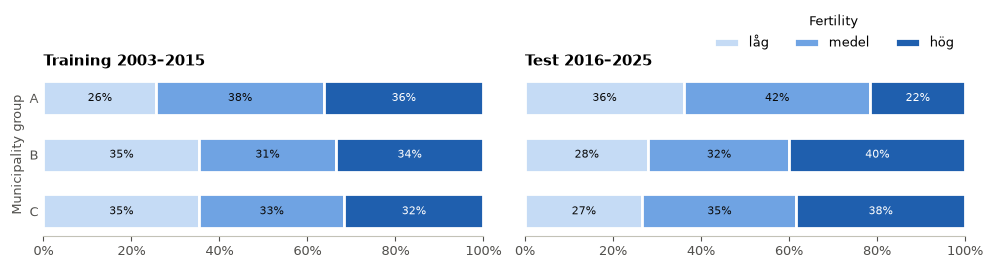

In [13]:
fig, axlar = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True)
for ax, del_, rubrik in zip(axlar, ["traning", "test"],
                            [f"Training {ar_tran.min()}–{ar_tran.max()}", f"Test {ar_test.min()}–{ar_test.max()}"]):
    d = underlag.loc[underlag["del"] == del_]
    tabell = pd.crosstab(d["kommungrupp"], d["fruktsamhet_klass"], normalize="index")
    tabell = tabell.loc[KATEGORIER["kommungrupp"][::-1], KATEGORIER["fruktsamhet"]]
    vanster = pd.Series(0.0, index=tabell.index)
    for klass in tabell.columns:
        staplar = ax.barh(tabell.index, tabell[klass], left=vanster, height=0.6,
                          color=KLASSFARG[klass], edgecolor="white", linewidth=2, label=klass)
        ax.bar_label(staplar, labels=[f"{v:.0%}" for v in tabell[klass]], label_type="center",
                     color="white" if klass == "hög" else "#0b0b0b", fontsize=8)
        vanster += tabell[klass]
    ax.set_title(rubrik, loc="left")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
axlar[0].set_ylabel("Municipality group")
axlar[1].legend(title="Fertility", ncols=3, frameon=False, loc="lower right", bbox_to_anchor=(1, 1.08))
fig.tight_layout()
fig.savefig(RESULTAT / "arm_baslinje.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 2: Do the rules hold on the test years?

Each dot is one of the candidate rules that answer the research question. The x-axis is the added confidence on the training years and the y-axis the same measure on the test years. The dashed line is the selection threshold `MIN_TILLSKOTT`. A rule that generalises lies in the shaded area, selected on the training years and positive on the test years. Hollow dots rest on fewer than `MIN_AR_TEST` test years and cannot be tested reliably. Every selected rule is named. Rules with identical measures lie on top of each other and share one label.

If the business cycle had a stable effect, the dots would follow the diagonal. A cloud without any clear direction means that what the rules found on the training years does not recur.

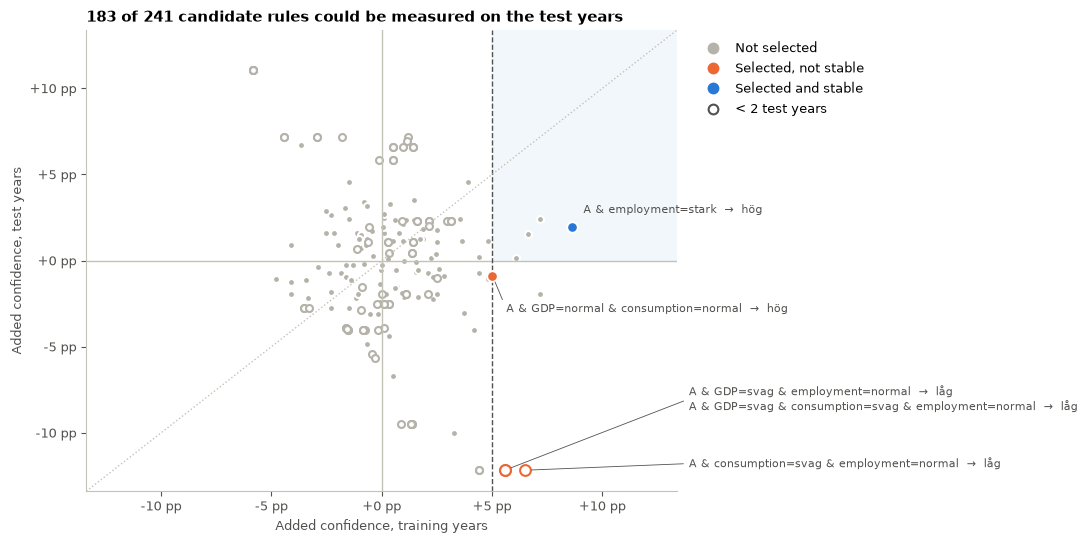

In [ ]:
provad = matta.dropna(subset=["tillskott_test"])
vald = provad.index.isin(valda.index)
stabil = provad.index.isin(valda.index[valda["stabil"]])
provbar = provad["antal_ar_test"] >= MIN_AR_TEST

fig, ax = plt.subplots(figsize=(11, 5.5))  
grans = max(provad[["tillskott_tran", "tillskott_test"]].abs().max()) * 1.1
ax.axvspan(MIN_TILLSKOTT, grans, ymin=0.5, color=BLA, alpha=0.06, lw=0)
ax.axhline(0, color=LINJE, lw=1)
ax.axvline(0, color=LINJE, lw=1)
ax.axvline(MIN_TILLSKOTT, color=TEXT, lw=1, ls="--")
ax.plot([-grans, grans], [-grans, grans], color=LINJE, lw=1, ls=":")

for mask, farg, storlek, z in [(~vald, GRA, 25, 1), (vald & ~stabil, ORANGE, 60, 3), (stabil, BLA, 60, 3)]:
    for fylld in [True, False]:
        m = mask & (provbar == fylld)
        ax.scatter(provad.loc[m, "tillskott_tran"], provad.loc[m, "tillskott_test"], s=storlek, zorder=z,
                   facecolor=farg if fylld else "white", edgecolor="white" if fylld else farg, linewidth=1.5)

# Name every selected rule. Rules with identical measures (GDP and consumption were weak in
# the same years) lie on top of each other and share one label.
etiketter = (
    provad.loc[vald]
    .assign(regel=lambda d: [kort_regel(v, s) for v, s in zip(d["villkor"], d["slutled"])],
            stabil=lambda d: d.index.isin(valda.index[valda["stabil"]]))
    .groupby(["tillskott_tran", "tillskott_test", "stabil"], sort=False)["regel"].agg("\n".join)
    .reset_index()
)
linje = dict(arrowstyle="-", color=TEXT, lw=0.6, shrinkA=2, shrinkB=5, relpos=(0, 0.5))
langst_ned = ~etiketter["stabil"] & (etiketter["tillskott_test"] < -0.6 * grans)
for _, rad in etiketter.loc[~langst_ned].iterrows():
    xy = (rad["tillskott_tran"], rad["tillskott_test"])
    if rad["stabil"]:
        ax.annotate(rad["regel"], xy, xytext=(8, 10), textcoords="offset points", fontsize=8, color=TEXT)
    else:
        ax.annotate(rad["regel"], xy, xytext=(10, -24), textcoords="offset points",
                    fontsize=8, color=TEXT, va="center", arrowprops=linje)


for k, (_, rad) in enumerate(etiketter.loc[langst_ned].sort_values("tillskott_tran", ascending=False).iterrows()):
    ax.annotate(rad["regel"], (rad["tillskott_tran"], rad["tillskott_test"]), xytext=(1.02, 0.06 + 0.14 * k),
                textcoords="axes fraction", fontsize=8, color=TEXT, va="center", arrowprops=linje)

ax.set_xlim(-grans, grans)
ax.set_ylim(-grans, grans)
ax.xaxis.set_major_formatter(lambda x, _: f"{x * 100:+.0f} pp")
ax.yaxis.set_major_formatter(lambda x, _: f"{x * 100:+.0f} pp")
ax.set_xlabel("Added confidence, training years")
ax.set_ylabel("Added confidence, test years")
ax.set_title(f"{len(provad)} of {len(matta)} candidate rules could be measured on the test years", loc="left")

punkt = lambda farg, fylld=True: Line2D([], [], ls="", marker="o", markersize=7, markeredgewidth=1.5,
                                         markerfacecolor=farg if fylld else "white", markeredgecolor=farg)
ax.legend([punkt(GRA), punkt(ORANGE), punkt(BLA), punkt(TEXT, False)],
          ["Not selected", "Selected, not stable", "Selected and stable", f"< {MIN_AR_TEST} test years"],
          frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(RESULTAT / "arm_tran_mot_test.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 3: The selected rules against their baseline

For each selected rule, the grey dot is the baseline (the municipality group alone) and the coloured dot is the confidence with the business cycle condition added. The distance between them is the added confidence. Blue means the condition raises the confidence and orange that it lowers it. A rule that holds should be blue in both panels. Hollow dots rest on fewer than `MIN_AR_TEST` test years.

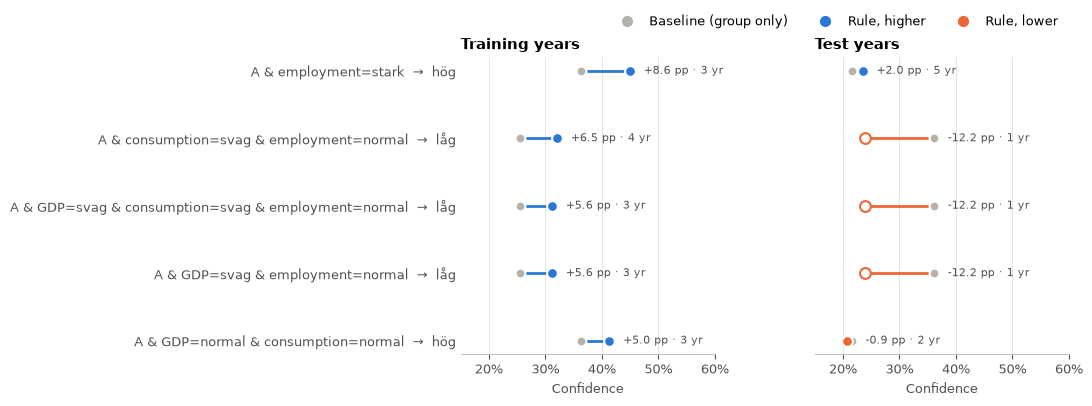

In [15]:
etiketter = [kort_regel(v, s) for v, s in zip(valda["villkor"], valda["slutled"])][::-1]
fig, axlar = plt.subplots(1, 2, figsize=(11, 0.55 * len(valda) + 1.4), sharey=True, sharex=True)
for ax, suffix, rubrik in zip(axlar, ["tran", "test"], ["Training years", "Test years"]):
    for y, (_, rad) in enumerate(valda.iloc[::-1].iterrows()):
        bas, konf, tillskott = rad[f"bas_confidence_{suffix}"], rad[f"confidence_{suffix}"], rad[f"tillskott_{suffix}"]
        if pd.isna(konf):
            ax.text(0.01, y, "never occurs", va="center", color=TEXT, fontsize=8, transform=ax.get_yaxis_transform())
            continue
        farg = BLA if tillskott > 0 else ORANGE
        fylld = suffix == "tran" or rad["antal_ar_test"] >= MIN_AR_TEST
        ax.plot([bas, konf], [y, y], color=farg, lw=2, zorder=1)
        ax.scatter(bas, y, s=50, color=GRA, edgecolor="white", linewidth=1.5, zorder=2)
        ax.scatter(konf, y, s=60, facecolor=farg if fylld else "white", edgecolor="white" if fylld else farg,
                   linewidth=1.5, zorder=3)
        ar = rad[f"antal_ar_{suffix}"]
        ax.annotate(f"{tillskott * 100:+.1f} pp · {ar} yr", (max(bas, konf), y), xytext=(10, 0),
                    textcoords="offset points", va="center", fontsize=8, color=TEXT)
    ax.set_title(rubrik, loc="left")
    ax.set_yticks(range(len(valda)), etiketter)
    ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x", color=LINJE, lw=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.set_xlabel("Confidence")
axlar[0].set_xlim(0.15, 0.6)
axlar[1].legend([Line2D([], [], ls="", marker="o", markersize=7, color=GRA),
                 Line2D([], [], ls="", marker="o", markersize=7, color=BLA),
                 Line2D([], [], ls="", marker="o", markersize=7, color=ORANGE)],
                ["Baseline (group only)", "Rule, higher", "Rule, lower"],
                frameon=False, ncols=3, loc="lower right", bbox_to_anchor=(1, 1.06))
fig.tight_layout()
fig.savefig(RESULTAT / "arm_valda_regler.png", dpi=150, bbox_inches="tight")
plt.show()